# Order-2 gate interactions for a QAOA circuit: TN-SHAP-Q vs exact enumeration

**Standalone, self-contained notebook** (only `numpy`, `matplotlib`, `qiskit`; no `qshaptools` needed
here). Runs top-to-bottom.

This reuses the **identical Section 4.2 gate game** from `tnshapq_vs_qshaptools_gates.ipynb`: the QAOA
ansatz for $H=Z_0Z_1+2Z_0-3Z_2$, decomposed to $m{=}13$ elementary gate players, same observable and
$|0\rangle$ input, and the same channel-mixture multilinear extension $F_g$ (Prop. 4 / gate
proposition): gate $i$ is kept with weight $z_i$ via $\mathcal E_i^{z_i}(\rho)=z_i g_i\rho g_i^\dagger+(1-z_i)\rho$,
so $F_g(z)=\sum_S\big(\prod_{i\in S}z_i\prod_{i\notin S}(1-z_i)\big)v_g(S)$ with $v_g(S)=\mathrm{Tr}(H\,U_S|0\rangle\langle0|U_S^\dagger)$.

We compute every pairwise interaction index $I(\{i,j\})=\int_0^1\partial_i\partial_j F_g(t\mathbf 1)\,dt$
(App. A, Def. 4) two ways and check machine-precision agreement, then read off the circuit structure the
interactions expose.

In [1]:
import math, time
from itertools import combinations
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from qiskit import QuantumCircuit
from qiskit.circuit.library import QAOAAnsatz
from qiskit.quantum_info import Statevector, SparsePauliOp, Operator
np.set_printoptions(precision=4, suppress=True)
print("imports OK")

imports OK


## 1. The Section 4.2 gate game (identical to the gate notebook; circuit not rebuilt)

In [2]:
H = SparsePauliOp.from_list([("ZZI", 1.0), ("ZII", 2.0), ("ZIZ", -3.0)])
qc = QAOAAnsatz(cost_operator=H, reps=1)
for _ in range(3):
    qc = qc.decompose()
qc = qc.assign_parameters([0.3] * len(qc.parameters))
m = len(qc.data); nq = qc.num_qubits; dim = 1 << nq
Hm = Operator(H).data

# per-gate unitary on the full register + metadata (layer, qubits)
Us = []; meta = []
for idx, ci in enumerate(qc.data):
    q1 = QuantumCircuit(nq); q1.append(ci.operation, ci.qubits); Us.append(Operator(q1).data)
    meta.append({'idx': idx, 'name': ci.operation.name,
                 'qubits': [qc.find_bit(q).index for q in ci.qubits]})

def gate_layer(name):
    if name == 'u': return 'init'    # Hadamards (uniform superposition)
    if name == 'r': return 'mixer'   # RX mixer rotations
    return 'cost'                    # cx / rz / p  (cost-Hamiltonian evolution)
for g in meta: g['layer'] = gate_layer(g['name'])

print(f"m={m} gate players on nq={nq} qubits; exact game = 2^{m} = {1<<m} evaluations")
print("H terms (qiskit labels):", list(zip(H.paulis.to_labels(), [float(c.real) for c in H.coeffs])))
print("\ngates (circuit order):")
for g in meta:
    print(f"  [{g['idx']:2d}] {g['name']:3s} q{g['qubits']}  layer={g['layer']}")

m=13 gate players on nq=3 qubits; exact game = 2^13 = 8192 evaluations
H terms (qiskit labels): [('ZZI', 1.0), ('ZII', 2.0), ('ZIZ', -3.0)]

gates (circuit order):
  [ 0] u   q[0]  layer=init
  [ 1] u   q[1]  layer=init
  [ 2] u   q[2]  layer=init
  [ 3] cx  q[1, 2]  layer=cost
  [ 4] rz  q[2]  layer=cost
  [ 5] cx  q[1, 2]  layer=cost
  [ 6] r   q[1]  layer=mixer
  [ 7] p   q[2]  layer=cost
  [ 8] cx  q[0, 2]  layer=cost
  [ 9] rz  q[2]  layer=cost
  [10] cx  q[0, 2]  layer=cost
  [11] r   q[0]  layer=mixer
  [12] r   q[2]  layer=mixer


## 2. Exact route (A): full game $v_g$, Harsanyi dividends, Grabisch--Roubens index

$v_g(S)$ over all $2^m$ coalitions (pure-state application of the kept gates), Harsanyi dividends
$a_T=\sum_{L\subseteq T}(-1)^{|T|-|L|}v_g(L)$ by a fast Mobius transform, then
$I(S)=\sum_{T\supseteq S} a_T/(|T|-|S|+1)$ (and $\phi_i=\sum_{T\ni i}a_T/|T|$).

In [3]:
def vg_mask(mask):
    psi = np.zeros(dim, complex); psi[0] = 1.0
    for gi in range(m):
        if (mask >> gi) & 1: psi = Us[gi] @ psi
    return float(np.real(np.vdot(psi, Hm @ psi)))

t0 = time.time()
v = np.array([vg_mask(mask) for mask in range(1 << m)])
print(f"full game: {1<<m} values in {time.time()-t0:.1f}s; v(empty)={v[0]:+.4f}, v(all)={v[-1]:+.4f}")

# Harsanyi dividends via fast (Mobius) subset transform
a = v.astype(float).copy()
for bit in range(m):
    step = 1 << bit
    for mask in range(1 << m):
        if mask & step: a[mask] -= a[mask ^ step]
pc = np.array([bin(x).count('1') for x in range(1 << m)])

# first-order Shapley from dividends: phi_i = sum_{T ni i} a_T/|T|
phi = np.zeros(m)
for mask in range(1 << m):
    if a[mask] == 0.0 or pc[mask] == 0: continue
    w = a[mask] / pc[mask]; mm = mask
    while mm:
        low = mm & (-mm); phi[low.bit_length()-1] += w; mm ^= low

# exact pairwise interaction: I({i,j}) = sum_{T supseteq {i,j}} a_T/(|T|-1)
pairs = list(combinations(range(m), 2))
I_exact = {}
for (i, j) in pairs:
    bij = (1 << i) | (1 << j); acc = 0.0
    for mask in range(1 << m):
        if (mask & bij) == bij and a[mask] != 0.0:
            acc += a[mask] / (pc[mask] - 1)
    I_exact[(i, j)] = acc
print(f"computed {len(pairs)} exact pairwise indices and {m} first-order Shapley values")

full game: 8192 values in 0.1s; v(empty)=+0.0000, v(all)=+1.8128


computed 78 exact pairwise indices and 13 first-order Shapley values


## 3. TN-SHAP-Q route (B): channel-mixture $F_g$, Owen mixed second difference

$\Delta_{ij}(t)=F_g(1,1,t..)-F_g(1,0,t..)-F_g(0,1,t..)+F_g(0,0,t..)$ integrated by $M$-node
Gauss--Legendre on $[0,1]$. $\partial_i\partial_j F_g$ has diagonal degree $\le m-2$, so
$M=\lceil(m-1)/2\rceil=6$ is exact. Cost $=2^{|S|}M=24$ evaluations of $F_g$ per pair.

In [4]:
def F(z):
    # channel-mixture multilinear extension: gate gi kept with weight z[gi]
    rho = np.zeros((dim, dim), complex); rho[0, 0] = 1.0
    for gi, U in enumerate(Us):
        p = float(z[gi])
        if p == 1.0:   rho = U @ rho @ U.conj().T
        elif p != 0.0: rho = p * (U @ rho @ U.conj().T) + (1 - p) * rho
    return float(np.real(np.trace(Hm @ rho)))

def owen_pair_interaction(M):
    nodes, wts = np.polynomial.legendre.leggauss(M); t = 0.5*(nodes+1); w = 0.5*wts
    I = {}; evals = 0
    for (i, j) in pairs:
        acc = 0.0
        for tm, wm in zip(t, w):
            z = np.full(m, tm); z[i] = 1.0; z[j] = 1.0; Fpp = F(z)
            z = np.full(m, tm); z[i] = 1.0; z[j] = 0.0; Fpm = F(z)
            z = np.full(m, tm); z[i] = 0.0; z[j] = 1.0; Fmp = F(z)
            z = np.full(m, tm); z[i] = 0.0; z[j] = 0.0; Fmm = F(z)
            acc += wm * (Fpp - Fpm - Fmp + Fmm); evals += 4
        I[(i, j)] = acc
    return I, evals

M = (m - 1 + 1) // 2  # ceil((m-1)/2)
t0 = time.time()
I_owen, owen_evals = owen_pair_interaction(M)
print(f"Owen M={M}: {owen_evals} F_g-evaluations ({owen_evals//len(pairs)}/pair) in {time.time()-t0:.1f}s")

Owen M=6: 1872 F_g-evaluations (24/pair) in 0.3s


## 4. The two routes agree to machine precision

In [5]:
diffs = np.array([abs(I_exact[p] - I_owen[p]) for p in pairs])
mae = float(diffs.mean()); maxerr = float(diffs.max())
assert maxerr < 1e-13, f"agreement worse than expected: {maxerr:.2e}"
print(f"TN-SHAP-Q (Owen, M={M}) vs exact 2^m enumeration:")
print(f"  max|I_exact - I_owen| = {maxerr:.3e}   MAE = {mae:.3e}")
print(f"  cost: Owen = {owen_evals} F_g-evals ({owen_evals//len(pairs)}/pair for {len(pairs)} pairs); "
      f"full game = 2^m = {1<<m}")
print(f"  -> exact at O(m^2 M) = {owen_evals} vs O(2^m) = {1<<m}; here Owen is genuinely cheaper")

TN-SHAP-Q (Owen, M=6) vs exact 2^m enumeration:
  max|I_exact - I_owen| = 3.331e-15   MAE = 3.587e-16
  cost: Owen = 1872 F_g-evals (24/pair for 78 pairs); full game = 2^m = 8192
  -> exact at O(m^2 M) = 1872 vs O(2^m) = 8192; here Owen is genuinely cheaper


## 5. Interaction dominance: single- and double-layer ablations $\approx 0$

If a coalition is one whole layer (or two), the energy stays near the $v(\emptyset)$ baseline; the full
QAOA energy emerges only from the init$\times$cost$\times$mixer combination, so it is carried by
interactions, not additive contributions.

In [6]:
def vg_set(idxset):
    psi = np.zeros(dim, complex); psi[0] = 1.0
    for gi in range(m):
        if gi in idxset: psi = Us[gi] @ psi
    return float(np.real(np.vdot(psi, Hm @ psi)))

L = {name: {g['idx'] for g in meta if g['layer'] == name} for name in ('init', 'cost', 'mixer')}
print(f"v(empty)      = {vg_set(set()):+.4f}")
print(f"v(init)       = {vg_set(L['init']):+.4f}")
print(f"v(cost)       = {vg_set(L['cost']):+.4f}")
print(f"v(mixer)      = {vg_set(L['mixer']):+.4f}")
print(f"v(init+cost)  = {vg_set(L['init']|L['cost']):+.4f}")
print(f"v(init+mixer) = {vg_set(L['init']|L['mixer']):+.4f}")
print(f"v(cost+mixer) = {vg_set(L['cost']|L['mixer']):+.4f}")
print(f"v(all)        = {vg_set(set(range(m))):+.4f}   <- only the full combination realises the energy")

v(empty)      = +0.0000
v(init)       = +0.0000
v(cost)       = +0.0000
v(mixer)      = +0.2883
v(init+cost)  = +0.0000
v(init+mixer) = +0.0000
v(cost+mixer) = +0.2883
v(all)        = +1.8128   <- only the full combination realises the energy


## 6. Structure: largest couplings, term/qubit alignment, and "important only in combination\"

In [7]:
absI = {p: abs(I_exact[p]) for p in pairs}
order = sorted(pairs, key=lambda p: -absI[p])
def lab(i):
    g = meta[i]; nm = {'u':'H','r':'RX','p':'P','rz':'RZ','cx':'CX'}.get(g['name'], g['name'])
    return f"g{i}:{nm} q{''.join(map(str, g['qubits']))}({g['layer']})"
print("top-6 |I_ij| pairs:")
for p in order[:6]:
    print(f"  I={I_exact[p]:+.4f}   {lab(p[0])}  x  {lab(p[1])}")

tot = np.array([sum(absI[tuple(sorted((i, j)))] for j in range(m) if j != i) for i in range(m)])
rank_phi = {g: r for r, g in enumerate(sorted(range(m), key=lambda i: -abs(phi[i])))}
rank_tot = {g: r for r, g in enumerate(sorted(range(m), key=lambda i: -tot[i]))}
print("\nper-gate first-order phi vs total interaction sum_j|I_ij| (rank in parentheses, 0=largest):")
for i in range(m):
    flag = "  <-- important only in combination" if (rank_phi[i] >= m//2 and rank_tot[i] <= 2) else ""
    print(f"  {lab(i):20s} phi={phi[i]:+.4f} (#{rank_phi[i]:2d})   sum|I|={tot[i]:.4f} (#{rank_tot[i]:2d}){flag}")

# the standout combination-only gate
combo = min(range(m), key=lambda i: (rank_tot[i], rank_phi[i] - rank_tot[i]))
g3 = max(range(m), key=lambda i: tot[i])
print(f"\nlargest total interaction: {lab(g3)}  (sum|I|={tot[g3]:.3f}, first-order rank #{rank_phi[g3]})")

top-6 |I_ij| pairs:
  I=+1.9284   g8:CX q02(cost)  x  g10:CX q02(cost)
  I=-0.8587   g0:H q0(init)  x  g2:H q2(init)
  I=-0.8197   g0:H q0(init)  x  g8:CX q02(cost)
  I=+0.6311   g10:CX q02(cost)  x  g11:RX q0(mixer)
  I=-0.5458   g2:H q2(init)  x  g8:CX q02(cost)
  I=+0.5350   g1:H q1(init)  x  g2:H q2(init)

per-gate first-order phi vs total interaction sum_j|I_ij| (rank in parentheses, 0=largest):
  g0:H q0(init)        phi=+0.6892 (# 0)   sum|I|=2.7616 (# 3)
  g1:H q1(init)        phi=-0.0335 (# 9)   sum|I|=2.2964 (# 4)
  g2:H q2(init)        phi=-0.2982 (# 3)   sum|I|=3.2193 (# 2)
  g3:CX q12(cost)      phi=+0.0448 (# 8)   sum|I|=0.9210 (#10)
  g4:RZ q2(cost)       phi=+0.0174 (#10)   sum|I|=0.8910 (#11)
  g5:CX q12(cost)      phi=+0.1942 (# 6)   sum|I|=1.6113 (# 7)
  g6:RX q1(mixer)      phi=-0.0117 (#11)   sum|I|=0.4747 (#12)
  g7:P q2(cost)        phi=-0.1943 (# 5)   sum|I|=1.3546 (# 8)
  g8:CX q02(cost)      phi=+0.0863 (# 7)   sum|I|=4.1821 (# 0)  <-- important only in combin

## 7. Figure: $|I({i,j})|$ heatmap and $\phi_i$ vs $\sum_j|I_{ij}|$

Gates are ordered by layer (init, cost, mixer) then qubit. Saved to `gate_interactions.pdf` (paper
Figure) and `.png`.

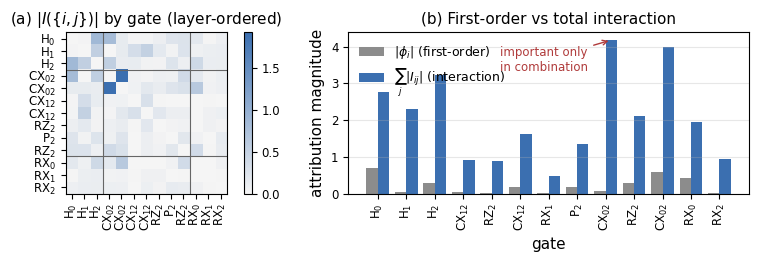

wrote ../gate_interactions.pdf and .png


In [8]:
plt.rcParams.update({'font.size': 11, 'axes.titlesize': 11, 'axes.labelsize': 11,
                     'xtick.labelsize': 8.5, 'ytick.labelsize': 8.5, 'legend.fontsize': 9})

# order gates by layer then qubit
lrank = {'init': 0, 'cost': 1, 'mixer': 2}
perm = sorted(range(m), key=lambda i: (lrank[meta[i]['layer']], min(meta[i]['qubits']), i))
def tick(i):
    g = meta[i]; nm = {'u':'H','r':'RX','p':'P','rz':'RZ','cx':'CX'}.get(g['name'], g['name'])
    return f"{nm}$_{{{''.join(map(str, g['qubits']))}}}$"
ticks = [tick(i) for i in perm]

Imat = np.zeros((m, m))
for (i, j) in pairs:
    Imat[i, j] = Imat[j, i] = abs(I_exact[(i, j)])
Imat_o = Imat[np.ix_(perm, perm)]

blue = LinearSegmentedColormap.from_list('gb', ['#f5f5f5', '#3b6fb0'])
fig, (a1, a2) = plt.subplots(1, 2, figsize=(9.4, 2.75), gridspec_kw={'width_ratios': [1.05, 1]})

im = a1.imshow(Imat_o, cmap=blue, vmin=0)
a1.set_xticks(range(m)); a1.set_yticks(range(m))
a1.set_xticklabels(ticks, rotation=90); a1.set_yticklabels(ticks)
# layer separators
bounds = []
acc = 0
for name in ('init', 'cost', 'mixer'):
    acc += sum(1 for i in perm if meta[i]['layer'] == name); bounds.append(acc)
for b in bounds[:-1]:
    a1.axhline(b - 0.5, color='0.4', lw=0.8); a1.axvline(b - 0.5, color='0.4', lw=0.8)
a1.set_title(r'(a) $|I(\{i,j\})|$ by gate (layer-ordered)')
fig.colorbar(im, ax=a1, fraction=0.046, pad=0.04)

# bar: phi vs sum|I| in circuit order
xb = np.arange(m); wid = 0.4
a2.bar(xb - wid/2, np.abs(phi), wid, color='0.55', label=r'$|\phi_i|$ (first-order)')
a2.bar(xb + wid/2, tot, wid, color='#3b6fb0', label=r'$\sum_j|I_{ij}|$ (interaction)')
a2.set_xticks(xb); a2.set_xticklabels([tick(i) for i in range(m)], rotation=90)
a2.set_xlabel('gate'); a2.set_ylabel('attribution magnitude')
a2.set_title(r'(b) First-order vs total interaction')
a2.legend(frameon=False, loc='upper left')
# mark the "important only in combination" gate (max sum|I|, low phi rank)
gstar = max(range(m), key=lambda i: tot[i])
a2.annotate('important only\nin combination', xy=(gstar + wid/2, tot[gstar]),
            xytext=(4.3, tot[gstar] * 0.80), fontsize=8.5,
            arrowprops=dict(arrowstyle='->', color='#b03b3b', lw=1.0), color='#b03b3b')
a2.grid(alpha=0.3, axis='y')

fig.tight_layout()
OUT = '.' if os.path.exists('requirements.txt') else '..'
fig.savefig(os.path.join(OUT, 'gate_interactions.pdf'), bbox_inches='tight')
fig.savefig(os.path.join(OUT, 'gate_interactions.png'), dpi=150, bbox_inches='tight')
plt.show()
print("wrote", os.path.join(OUT, 'gate_interactions.pdf'), "and .png")

## 8. Summary

* **Exactness.** All $\binom{13}{2}=78$ pairwise gate interaction indices from the Owen mixed second
  difference match exact $2^m$ Grabisch--Roubens enumeration to machine precision (max $\sim10^{-15}$),
  at $24$ $F_g$-evaluations per pair ($\sim$1872 total) versus $2^m=8192$ to build the game.
* **Interaction-dominated energy.** Single- and double-layer ablations leave $\langle H\rangle$ near
  the baseline; the QAOA energy emerges only from the full init$\times$cost$\times$mixer combination.
* **Structure.** The largest couplings sit on the gates implementing the dominant ($-3$) Hamiltonian
  term, led by the two CX gates that realise that ZZ coupling; a CX with small first-order Shapley but
  the largest total interaction is "important only in combination" --- invisible to additive attribution.